## image-to-text using an LLM

This notebook tests the multimodal (image-to-text) capabilities of the Mistral-Small-3.1-24B-Instruct model deployed on OpenShift AI with vLLM.

It allows you to send both text and image data to the model and receive a natural-language description or caption of the image. 

🧩 What the code does (step by step)

	1.	Load an image
    
	2.	Convert the image to base64
    
	3.	Build and send a chat-style multimodal request

In [1]:
#!pip install pillow matplotlib requests

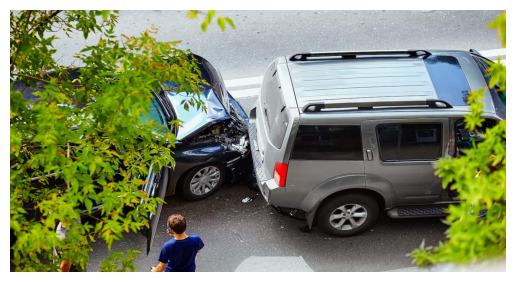

🧠 Model response:

The image depicts a car accident involving two vehicles: an SUV (sport utility vehicle) and a pickup truck. Here are the details:

1. **Vehicles Involved:**
   - **SUV:** Located on the left side of the image. It appears to be a dark-colored, modern SUV with a sleek design. The front end of the SUV is significantly damaged, with the hood crumpled and the windshield shattered.
   - **Pickup Truck:** Positioned on the right side of the image. It is a lighter-colored, gray SUV-type vehicle, possibly a minivan or crossover SUV. The front end of this vehicle is also damaged, with visible dents and possibly a broken headlight.

2. **Damage:** Both vehicles have sustained front-end damage, indicating a head-on collision. The SUV's damage is more pronounced, with visible crumpling and shattered glass. The pickup truck also shows signs of impact but appears to have less severe damage.

3. **Scene:**
   - The accident occurred on a roadway, possibly a highway or a main road, g

In [2]:
import base64
from PIL import Image
import matplotlib.pyplot as plt
import requests

# Encode local image as base64
with open("car-accident.jpg", "rb") as f:
    image_b64 = base64.b64encode(f.read()).decode("utf-8")

# Embed base64 as data URI
data_uri = f"data:image/jpeg;base64,{image_b64}"

# Display image
img = Image.open("car-accident.jpg")
plt.imshow(img)
plt.axis("off")
plt.show()

# Endpoint & headers
endpoint_url = "https://redhataimistral-small-quantizedw4a16-mistral.apps.cluster-d44sv.d44sv.sandbox2961.opentlc.com/v1/chat/completions"
headers = {"Content-Type": "application/json", "Authorization": "Bearer xxx"}   # replace xxx with your own token!!!


# ✅ Correct multimodal payload for Mistral-vLLM
data = {
    "model": "redhataimistral-small-quantizedw4a16",
    "messages": [
        {
            "role": "user",
            "content": [
                {"type": "text", "text": "Describe this image in detail."},
                {"type": "image_url", "image_url": {"url": data_uri}}
            ]
        }
    ],
    "max_tokens": 256
}

response = requests.post(endpoint_url, headers=headers, json=data)

print("🧠 Model response:\n")
print(response.json()["choices"][0]["message"]["content"])